<a href="https://colab.research.google.com/github/IshanKapadia-Data/Predicting-BankChurn/blob/main/Predicting_BankChurn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None

=== Summary Statistics ===
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  

<ipython-input-1-d01dcf96e5d0>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='viridis')


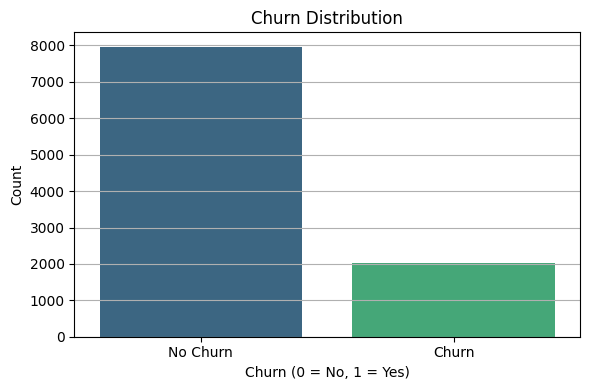

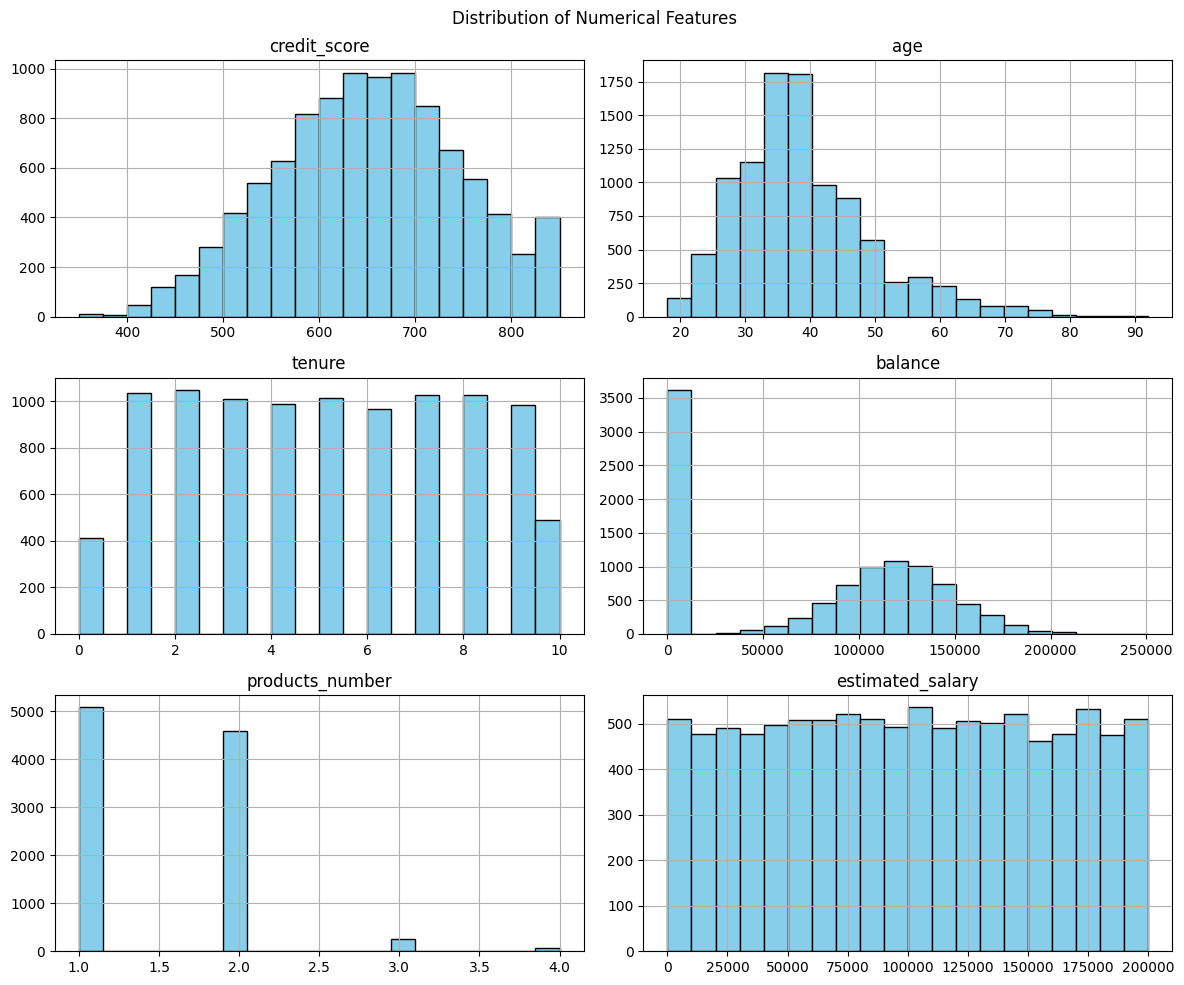

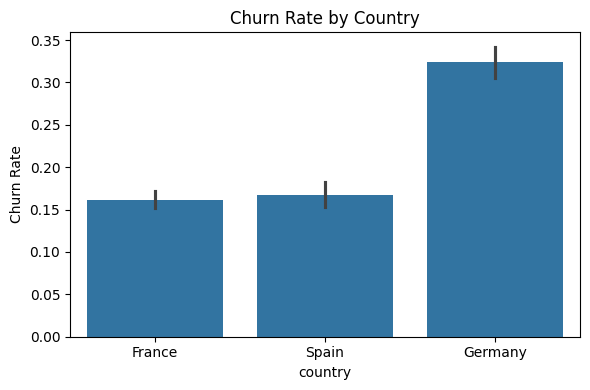

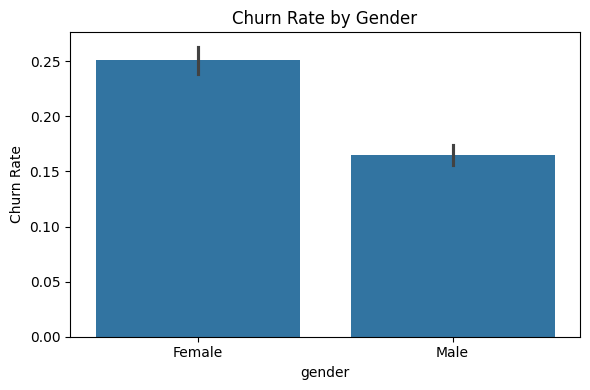

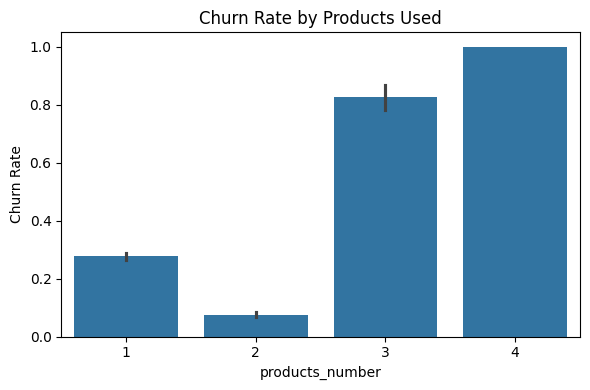

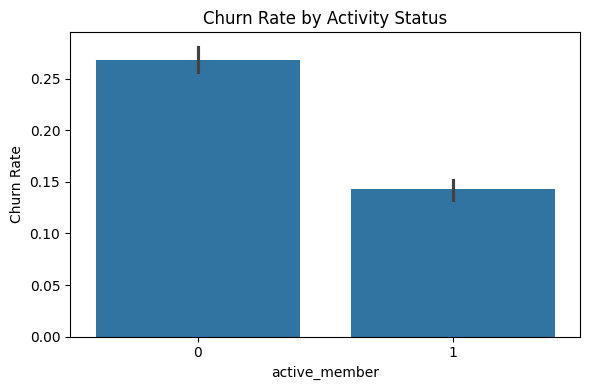

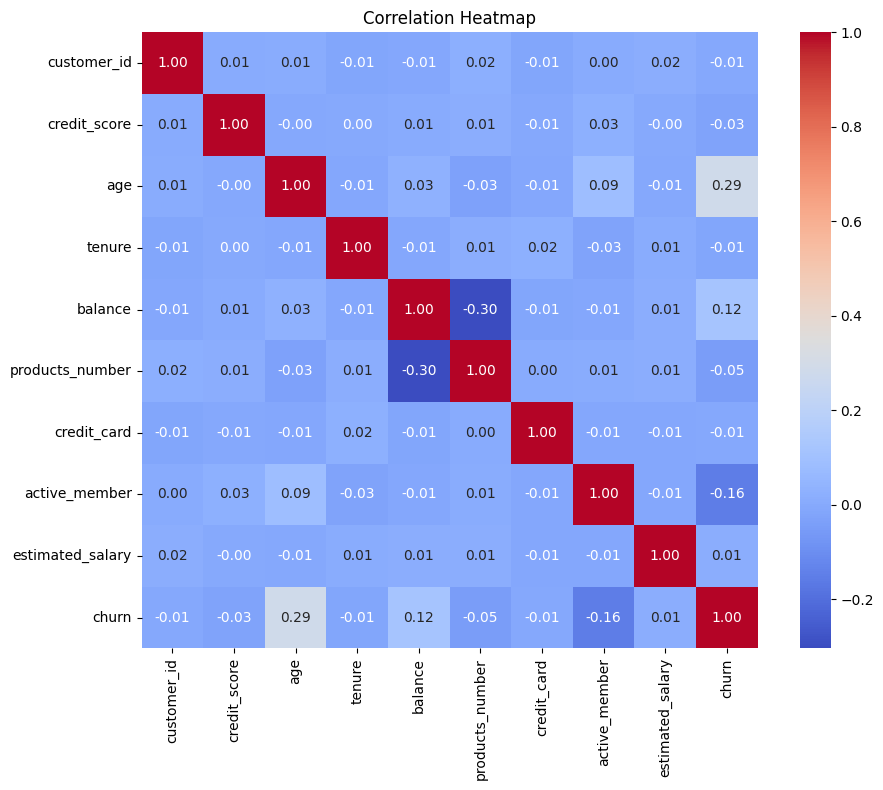

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Bank Customer Churn Prediction.csv")

# Basic Info
print("\n=== Dataset Info ===")
print(df.info())

print("\n=== Summary Statistics ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())

# Plot churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df, palette='viridis')
plt.title('Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Churn', 'Churn'])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Histograms for numerical features
num_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
df[num_cols].hist(bins=20, figsize=(12, 10), color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

# Churn rate by Country
plt.figure(figsize=(6,4))
sns.barplot(x='country', y='churn', data=df)
plt.title("Churn Rate by Country")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

# Churn rate by Gender
plt.figure(figsize=(6,4))
sns.barplot(x='gender', y='churn', data=df)
plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

# Churn rate by Number of Products
plt.figure(figsize=(6,4))
sns.barplot(x='products_number', y='churn', data=df)
plt.title("Churn Rate by Products Used")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

# Churn rate by Active Member
plt.figure(figsize=(6,4))
sns.barplot(x='active_member', y='churn', data=df)
plt.title("Churn Rate by Activity Status")
plt.ylabel("Churn Rate")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Drop customer_id as it's not predictive
df_model = df.drop(columns=['customer_id'])

# One-hot encode 'country' and 'gender'
df_model = pd.get_dummies(df_model, columns=['country', 'gender'], drop_first=True)

# Split features and target
X = df_model.drop('churn', axis=1)
y = df_model['churn']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47, stratify=y)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print shapes for verification
print("=== Data Shapes ===")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

=== Data Shapes ===
X_train: (8000, 11)
X_test: (2000, 11)
y_train: (8000,)
y_test: (2000,)



=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1593
           1       0.37      0.66      0.48       407

    accuracy                           0.71      2000
   macro avg       0.63      0.69      0.64      2000
weighted avg       0.79      0.71      0.73      2000

ROC-AUC Score: 0.7628090339954746

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.46      0.58       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC Score: 0.8623446250564895


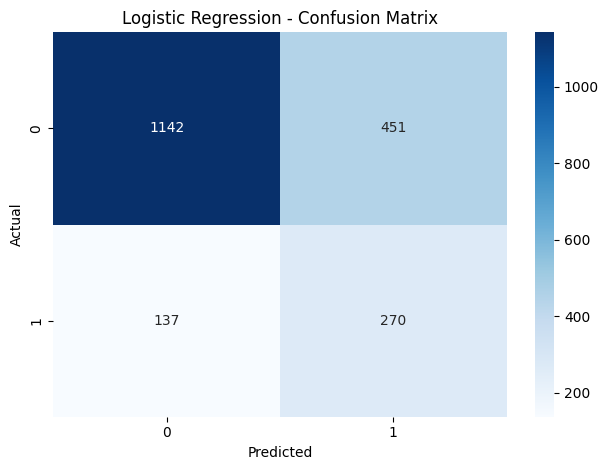

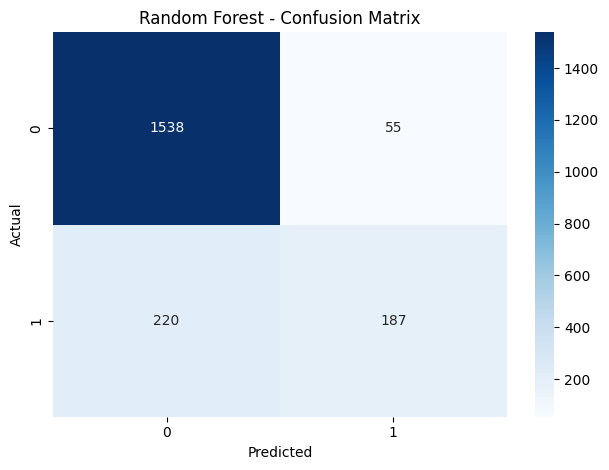

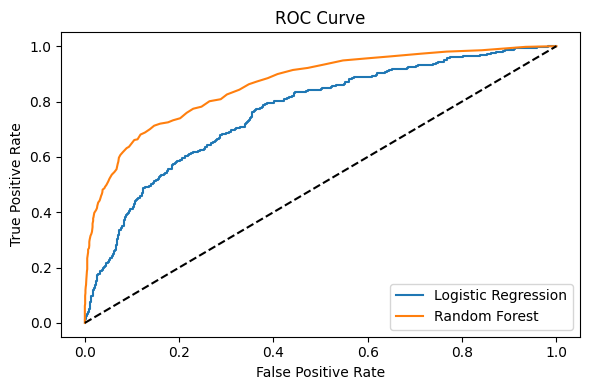

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# ========== Logistic Regression ==========
lr_model = LogisticRegression(class_weight='balanced', random_state=47)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_lr))

# ========== Random Forest ==========
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=47)
rf_model.fit(X_train, y_train)  # Tree models don't need scaling
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("\n=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_prob_rf))

# ========== Confusion Matrix ==========
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression - Confusion Matrix")
plot_conf_matrix(y_test, y_pred_rf, "Random Forest - Confusion Matrix")

# ========== ROC Curve ==========
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


<ipython-input-4-35a802d59d77>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')


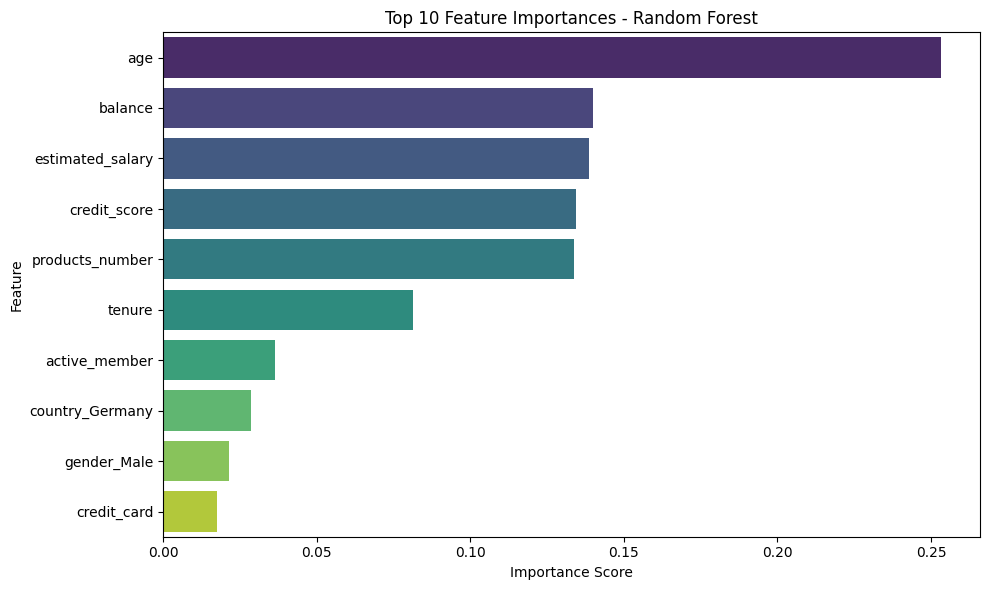


=== All Feature Importances ===
             Feature  Importance
1                age    0.253282
3            balance    0.140027
7   estimated_salary    0.138485
0       credit_score    0.134377
4    products_number    0.133828
2             tenure    0.081424
6      active_member    0.036243
8    country_Germany    0.028691
10       gender_Male    0.021425
5        credit_card    0.017529
9      country_Spain    0.014689


In [4]:
import numpy as np

# Get feature importances from the trained Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df.head(10), palette='viridis')
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Print full importance list (optional)
print("\n=== All Feature Importances ===")
print(feature_imp_df)


In [5]:
# ========== Predict Churn from User Input ==========

print("\n--- Enter Example Customer Details ---")
credit_score = int(input("Credit Score (e.g., 600): "))
country = input("Country (France, Germany, Spain): ").capitalize()
gender = input("Gender (Male/Female): ").capitalize()
age = int(input("Age (e.g., 40): "))
tenure = int(input("Tenure (years with bank, e.g., 3): "))
balance = float(input("Balance (e.g., 60000.0): "))
products_number = int(input("Number of Products (e.g., 2): "))
credit_card = int(input("Has Credit Card? (1 = Yes, 0 = No): "))
active_member = int(input("Is Active Member? (1 = Yes, 0 = No): "))
estimated_salary = float(input("Estimated Salary (e.g., 50000.0): "))

# Create DataFrame from input
user_input = pd.DataFrame([{
    'credit_score': credit_score,
    'country': country,
    'gender': gender,
    'age': age,
    'tenure': tenure,
    'balance': balance,
    'products_number': products_number,
    'credit_card': credit_card,
    'active_member': active_member,
    'estimated_salary': estimated_salary
}])

# Preprocess input
user_encoded = pd.get_dummies(user_input, columns=['country', 'gender'], drop_first=True)

# Ensure all expected columns exist
for col in X.columns:
    if col not in user_encoded.columns:
        user_encoded[col] = 0

# Reorder columns
user_encoded = user_encoded[X.columns]

# Scale for Logistic Regression
user_scaled = scaler.transform(user_encoded)

# Predict with Logistic Regression
lr_pred = lr_model.predict(user_scaled)[0]
lr_prob = lr_model.predict_proba(user_scaled)[0][1]

# Predict with Random Forest
rf_pred = rf_model.predict(user_encoded)[0]
rf_prob = rf_model.predict_proba(user_encoded)[0][1]

# Output
print("\n=== Prediction Results ===")
print("Logistic Regression:")
print(" - Churn Prediction:", "Yes" if lr_pred == 1 else "No")
print(" - Churn Probability: {:.2f}%".format(lr_prob * 100))

print("\nRandom Forest:")
print(" - Churn Prediction:", "Yes" if rf_pred == 1 else "No")
print(" - Churn Probability: {:.2f}%".format(rf_prob * 100))



--- Enter Example Customer Details ---
Credit Score (e.g., 600): 650
Country (France, Germany, Spain): France
Gender (Male/Female): Male
Age (e.g., 40): 25
Tenure (years with bank, e.g., 3): 3
Balance (e.g., 60000.0): 1000
Number of Products (e.g., 2): 3
Has Credit Card? (1 = Yes, 0 = No): 1
Is Active Member? (1 = Yes, 0 = No): 1
Estimated Salary (e.g., 50000.0): 60000

=== Prediction Results ===
Logistic Regression:
 - Churn Prediction: No
 - Churn Probability: 10.30%

Random Forest:
 - Churn Prediction: Yes
 - Churn Probability: 57.00%
